In [48]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import test as test
import networkx as nx
from tqdm import tqdm
import plotly.express as px

In [19]:
epidist_data = pd.read_csv('./Data/epidist.csv')
bepidist_data = pd.read_csv('./Data/bepidist.csv')
epidist_data =  epidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
epidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
'r_mean', 'r_min', 'r_max', 'V', 'T']
bepidist_data =  bepidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'V', 'T']
epidist_data = epidist_data.apply(pd.to_numeric)
bepidist_data = bepidist_data.apply(pd.to_numeric)

### Example of disease peaks differences depeding on utility shape parameter

0.0021999999999999797
0.013000000000000012
0.27979999999999994
0.41059999999999997


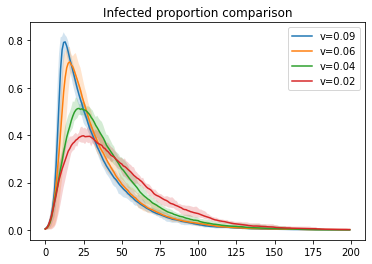

In [20]:
vs = [0.09, 0.06, 0.04, 0.02]
T = 7
n = 500

plt.figure()

for v in vs:

    epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
    bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]

    mean = (epidist['i_mean']/n).tolist()
    lower = (epidist['i_min']/n).tolist()
    upper = (epidist['i_max']/n).tolist()

    meanb = (bepidist['i_mean']/n).tolist()
    lowerb = (bepidist['i_min']/n).tolist()
    upperb = (bepidist['i_max']/n).tolist()

    diff = np.nanmax(mean) - np.nanmax(meanb)
    print(diff)

    # plt.plot(mean,'-b', label="Mean classic model")
    # # fill the area with black color, opacity 0.15
    # plt.fill_between(list(range(len(mean))), upper, lower, color="b", alpha=0.2)

    plt.plot(meanb, label=f"v={v}")
    # fill the area with black color, opacity 0.15
    plt.fill_between(list(range(len(meanb))), upperb, lowerb, alpha=0.2)

plt.title("Infected proportion comparison")
plt.legend(loc="upper right")

plt.show()

{0.3008,0.4106,0.3934,0.2798,0.1786,0.013,0.0154,0.074,0.0022,0.05},
{0.3984,0.2678,0.071,0.0072,0.0006,0.0686,0.0206,0.0172,0.0432,0.0072},
{0.3888,0.0674,0.0828,0.0434,0.099,0.003,0.025,0.0282,0.057,0.0926},
{0.0644,0.0062,0.0012,0.0346,0.011,0.0742,0.0374,0.0102,0.0826,0.0528},
{0.0836,0.0766,0.0238,0.0196,0.2168,0.1022,0.0052,0.0294,0.1264,0.0364},
{0.0216,0.0762,0.0152,0.0072,0.03,0.0698,0.0016,0.1034,0.0892,0.0786},
{0.032,0.1682,0.0036,0.0066,0.061,0.0638,0.112,0.0678,0.0036,0.0048},
{0.1054,0.0952,0.0058,0.0436,0.0268,0.0996,0.0112,0.0952,0.1466,0.0418},
{0.166,0.0704,0.0734,0.0302,0.0282,0.0702,0.0162,0.0148,0.0248,0.0108},


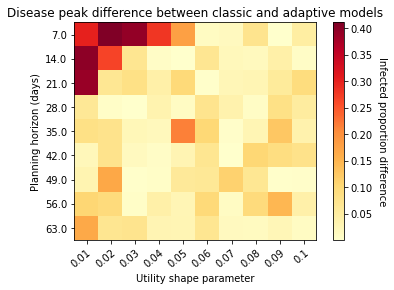

In [21]:
data_diff = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        
        epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean = (epidist['i_mean']/n).tolist()
        meanb = (bepidist['i_mean']/n).tolist()
        
        diff = np.nanmax(mean) - np.nanmax(meanb)
        
        data_diff = pd.concat([data_diff, pd.DataFrame({
            'V': [v],
            'T': [T],
            'diff': [np.abs(diff)]
        })], ignore_index=True)
plot1_data = data_diff.pivot(index='V', columns='T', values='diff')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = "YlOrRd")

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Infected proportion difference", rotation = -90, va = "bottom")
plt.title(f"Disease peak difference between classic and adaptive models")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

### Main figure: global vs local efforts

0.5711762324748587


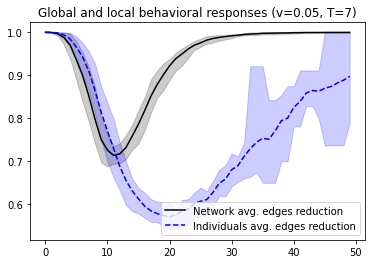

In [22]:
v = 0.05
T = 7
n = 500
epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]

mean_all = bepidist['edgecount_mean'].tolist()
lower_all = bepidist['edgecount_min'].tolist()
upper_all = bepidist['edgecount_max'].tolist()

mean_sus = bepidist['suscedgecount_mean'].tolist()
lower_sus = bepidist['suscedgecount_min'].tolist()
upper_sus = bepidist['suscedgecount_max'].tolist()

print(np.nanmin(bepidist['suscedgecount_mean'].tolist()))

plt.figure()
plt.plot(mean_all[0:50],'-k', label="Network avg. edges reduction")
plt.fill_between(range(50), upper_all[0:50], lower_all[0:50], color="k", alpha=0.2)
plt.plot(mean_sus[0:50], linestyle='--', color='b', label="Individuals avg. edges reduction")
plt.fill_between(range(50), upper_sus[0:50], lower_sus[0:50], color="b", alpha=0.2)
plt.title(f"Global and local behavioral responses (v={v}, T={T})")
plt.legend(loc="lower right")
plt.show()

### Min Avg. Edge Reduction (Global/Local)

{0.6686,0.6739,0.6707,0.7015,0.7137,0.8005,0.8985,0.9234,0.9405,0.9682},
{0.681,0.7048,0.8606,0.9556,0.967,0.9894,1.0,1.0,1.0,1.0},
{0.7137,0.9179,0.9749,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.8522,0.9743,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.9668,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.9837,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},


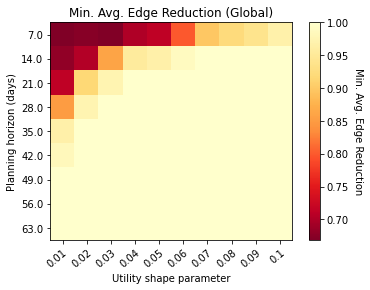

In [23]:
data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_sus = bepidist['edgecount_mean'].tolist()
        min_ctc_sus = np.nanmin(mean_sus)
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [min_ctc_sus]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap_r)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Min. Avg. Edge Reduction", rotation = -90, va = "bottom")
plt.title(f"Min. Avg. Edge Reduction (Global)")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

{0.6379,0.6456,0.6418,0.5825,0.5712,0.6948,0.8035,0.9442,0.8776,0.9643},
{0.6364,0.5926,0.7011,0.973,0.9805,0.9936,1.0,1.0,1.0,1.0},
{0.6704,0.9231,0.9857,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.8975,0.9844,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.9802,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{0.9908,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},
{1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0},


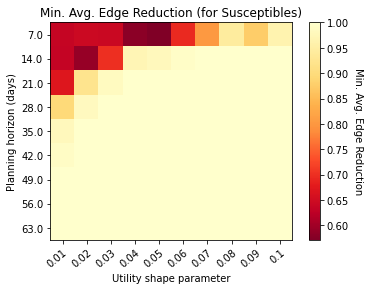

In [25]:
data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_sus = bepidist['suscedgecount_mean'].tolist()
        min_ctc_sus = np.nanmin(mean_sus)
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [min_ctc_sus]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap_r)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Min. Avg. Edge Reduction", rotation = -90, va = "bottom")
plt.title(f"Min. Avg. Edge Reduction (for Susceptibles)")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

### Day lag between min edge reductions (Global/Local)

{11,9,10,9,9,12,15,0,20,12},
{12,11,12,1,0,0,0,0,0,0},
{11,17,1,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{1,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},


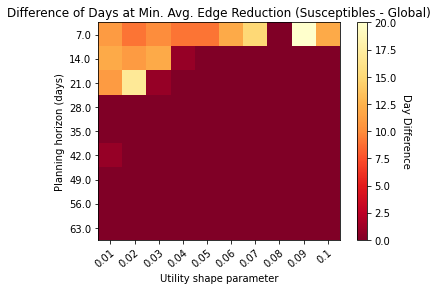

In [26]:
##### Reverse colormap
import matplotlib as mpl

def reverse_colourmap(cmap, name = 'my_cmap_r'):
    """
    In: 
    cmap, name 
    Out:
    my_cmap_r

    Explanation:
    t[0] goes from 0 to 1
    row i:   x  y0  y1 -> t[0] t[1] t[2]
                   /
                  /
    row i+1: x  y0  y1 -> t[n] t[1] t[2]

    so the inverse should do the same:
    row i+1: x  y1  y0 -> 1-t[0] t[2] t[1]
                   /
                  /
    row i:   x  y1  y0 -> 1-t[n] t[2] t[1]
    """        
    reverse = []
    k = []   

    for key in cmap._segmentdata:    
        k.append(key)
        channel = cmap._segmentdata[key]
        data = []

        for t in channel:                    
            data.append((1-t[0],t[2],t[1]))            
        reverse.append(sorted(data))    

    LinearL = dict(zip(k,reverse))
    my_cmap_r = mpl.colors.LinearSegmentedColormap(name, LinearL) 
    return my_cmap_r
cmap = mpl.cm.YlOrRd
cmap_r = reverse_colourmap(cmap)

# ------- #

data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_ctc_ = bepidist['edgecount_mean'].tolist()
        min_ctc_day_ = np.nanargmin(mean_ctc_)
        
        mean_ctc_sus_ = bepidist['suscedgecount_mean'].tolist()
        min_ctc_day_sus_ = np.nanargmin(mean_ctc_sus_)
        
        day_lag_ = min_ctc_day_sus_ - min_ctc_day_
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [day_lag_]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap_r)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Day Difference", rotation = -90, va = "bottom")
plt.title(f"Difference of Days at Min. Avg. Edge Reduction (Susceptibles - Global)")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

### Population distributions example

In [2]:
dist_example = pd.read_csv('./distribution_example.csv')

dist_example = dist_example.reset_index()
dist_example.columns = ['node', 'v', 'T']

print('Sub population 1: More risk averse. More susceptible to diminish contacts.')
print(dist_example.head(200)['v'].mean())
print(dist_example.head(200)['T'].mean())

print('Sub population 2: Less risk averse. Less susceptible to diminish contacts.')
print(dist_example.tail(300)['v'].mean())
print(dist_example.tail(300)['T'].mean())

Sub population 1: More risk averse. More susceptible to diminish contacts.
0.05
7.0
Sub population 2: Less risk averse. Less susceptible to diminish contacts.
0.08
16.0


[7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
[16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16

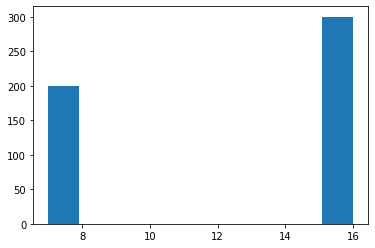

In [3]:
y = dist_example['T']
print(list(y[0:200]))
print(list(y[200:]))
plt.hist(y)
plt.show()

[0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.0

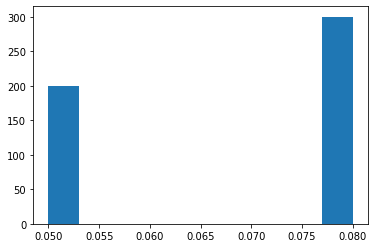

In [4]:
z = dist_example['v']
print(list(z[0:200]))
print(list(z[200:]))
plt.hist(z)
plt.show()

In [5]:
bepidist_data = pd.read_csv('./Data/Distribution_bepidist.csv')
bepidist_data

,day,s_mean,s_min,s_max,s_std,i_mean,i_min,i_max,i_std,r_mean,...,r_max,r_std,edgecount_mean,edgecount_min,edgecount_max,edgecount_std,suscedgecount_mean,suscedgecount_min,suscedgecount_max,suscedgecount_std
0,1,497.80,499,495,0.947607,2.10,4,0,0.952976,0.10,...,0,0.303046,0.999868,1.0,0.999177,0.000202,0.999980,1.0,0.999718,0.000059
1,2,495.30,499,488,2.674521,4.36,11,0,2.640037,0.34,...,0,0.658074,0.999210,1.0,0.996051,0.001034,0.999662,1.0,0.998317,0.000456
2,3,490.02,499,472,6.284058,9.20,26,0,6.091144,0.78,...,0,0.887326,0.996597,1.0,0.985190,0.003793,0.998343,1.0,0.992399,0.001889
3,4,480.22,499,450,12.519845,18.32,48,0,11.941080,1.46,...,0,1.402767,0.989979,1.0,0.964292,0.009496,0.994814,1.0,0.980176,0.005082
4,5,462.78,499,418,22.588863,34.28,76,0,21.260330,2.94,...,0,2.014336,0.976038,1.0,0.939773,0.018996,0.986681,1.0,0.964557,0.011075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,20.06,499,0,98.653467,0.22,3,0,0.545482,479.72,...,1,98.610353,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000
196,197,20.06,499,0,98.653467,0.22,3,0,0.545482,479.72,...,1,98.610353,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000
197,198,20.06,499,0,98.653467,0.20,3,0,0.534522,479.74,...,1,98.614444,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000
198,199,20.06,499,0,98.653467,0.20,3,0,0.534522,479.74,...,1,98.614444,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000


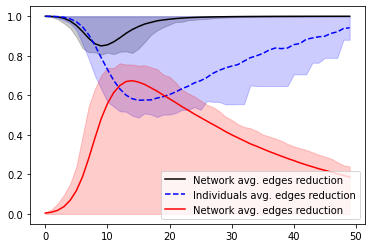

In [6]:
bepidist = bepidist_data.copy()

i_mean = bepidist['i_mean'].astype(float).tolist()
i_mean = [i/500 for i in i_mean]

i_min = bepidist['i_min'].astype(float).tolist()
i_min = [i/500 for i in i_min]

i_max = bepidist['i_max'].astype(float).tolist()
i_max = [i/500 for i in i_max]

mean_all = bepidist['edgecount_mean'].astype(float).tolist()
lower_all = bepidist['edgecount_min'].astype(float).tolist()
upper_all = bepidist['edgecount_max'].astype(float).tolist()

mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
lower_sus = bepidist['suscedgecount_min'].astype(float).tolist()
upper_sus = bepidist['suscedgecount_max'].astype(float).tolist()

plt.figure()
plt.plot(mean_all[0:50],'-k', label="Network avg. edges reduction")
plt.fill_between(range(50), upper_all[0:50], lower_all[0:50], color="k", alpha=0.2)
plt.plot(mean_sus[0:50], linestyle='--', color='b', label="Individuals avg. edges reduction")
plt.fill_between(range(50), upper_sus[0:50], lower_sus[0:50], color="b", alpha=0.2)
plt.plot(i_mean[0:50],'-r', label="Network avg. edges reduction")
plt.fill_between(range(50), i_max[0:50], i_min[0:50], color="r", alpha=0.2)
plt.legend(loc="lower right")
plt.show()

#### Examining contact behavior in subpopulations

In [7]:
bepcontacts = pd.read_csv('./Data/Distribution_bepidist_contacts.csv')
print(bepcontacts.shape)
bepcontacts

(25000, 202)


,index,node,day_0,day_1,day_2,day_3,day_4,day_5,day_6,day_7,...,day_190,day_191,day_192,day_193,day_194,day_195,day_196,day_197,day_198,day_199
0,0,0,23,23,23,23,21,20,18,14,...,23,23,23,23,23,23,23,23,23,23
1,0,1,22,22,22,22,22,21,18,18,...,22,22,22,22,22,22,22,22,22,22
2,0,2,22,22,22,22,21,19,16,13,...,22,22,22,22,22,22,22,22,22,22
3,0,3,27,26,26,26,25,20,22,23,...,27,27,27,27,27,27,27,27,27,27
4,0,4,20,20,20,15,15,16,16,20,...,20,20,20,20,20,20,20,20,20,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,49,495,26,26,26,26,26,26,26,26,...,26,26,26,26,26,26,26,26,26,26
24996,49,496,17,17,17,17,17,17,17,17,...,17,17,17,17,17,17,17,17,17,17
24997,49,497,21,21,21,19,21,17,19,20,...,21,21,21,21,21,21,21,21,21,21
24998,49,498,28,28,28,28,28,23,25,27,...,28,28,28,28,28,28,28,28,28,28


In [8]:
bepcontacts_long = pd.melt(bepcontacts, id_vars=['index', 'node'],
                           value_vars=[col for col in bepcontacts.columns if col.startswith('day')])
bepcontacts_long

,index,node,variable,value
0,0,0,day_0,23
1,0,1,day_0,22
2,0,2,day_0,22
3,0,3,day_0,27
4,0,4,day_0,20
...,...,...,...,...
4999995,49,495,day_199,26
4999996,49,496,day_199,17
4999997,49,497,day_199,21
4999998,49,498,day_199,28


In [9]:
bepcontacts_long_max = bepcontacts_long.groupby(['index', 'node'])['value'].max().reset_index()
bepcontacts_long_max.columns = ['index', 'node', 'value_max']
bepcontacts_long_max

,index,node,value_max
0,0,0,23
1,0,1,22
2,0,2,22
3,0,3,27
4,0,4,20
...,...,...,...
24995,49,495,26
24996,49,496,17
24997,49,497,21
24998,49,498,28


In [76]:
bepcontacts_long_norm = bepcontacts_long.merge(bepcontacts_long_max, left_on=['index', 'node'], right_on=['index', 'node'])
bepcontacts_long_norm['norm_value'] = bepcontacts_long_norm['value']/bepcontacts_long_norm['value_max']
bepcontacts_long_norm['pop'] = np.where(bepcontacts_long_norm['node']<200, 1, 2)
bepcontacts_long_norm = bepcontacts_long_norm.rename(columns={'variable':'day'})
bepcontacts_long_norm['day'] = bepcontacts_long_norm['day'].apply(lambda x: int(x.replace('day_','')))
bepcontacts_long_norm

,index,node,day,value,value_max,norm_value,pop
0,0,0,0,23,23,1.000000,1
1,0,0,1,23,23,1.000000,1
2,0,0,2,23,23,1.000000,1
3,0,0,3,23,23,1.000000,1
4,0,0,4,21,23,0.913043,1
...,...,...,...,...,...,...,...
4999995,49,499,195,16,16,1.000000,2
4999996,49,499,196,16,16,1.000000,2
4999997,49,499,197,16,16,1.000000,2
4999998,49,499,198,16,16,1.000000,2


In [103]:
# bepcontacts_long_norm[(bepcontacts_long_norm['node']==0) & (bepcontacts_long_norm['day']==11)]
# bepcontacts_long_norm[(bepcontacts_long_norm['node']==0) & (bepcontacts_long_norm['index']==44)].head(60)

In [95]:
df = bepcontacts_long_norm.groupby(['pop', 'day'], as_index=False).agg({'norm_value': ['mean', 'max', 'min', 'std']})

df.columns = df.columns.droplevel()
df.columns = ['pop', 'day', 'mean', 'max', 'min', 'std']

df['lower'] = df['mean'] - df['std']
df['upper'] = df['mean'] + df['std']
df['upper'] = df['upper'].apply(lambda x: min(x,1))

df = df.sort_values(by=['day'])
print(df['max'].unique())

df

[1.]


,pop,day,mean,max,min,std,lower,upper
0,1,0,0.999769,1.0,0.896552,0.003319,0.996449,1.0
200,2,0,0.999951,1.0,0.863636,0.001749,0.998202,1.0
1,1,1,0.998758,1.0,0.777778,0.008662,0.990096,1.0
201,2,1,0.999584,1.0,0.806452,0.006154,0.993431,1.0
2,1,2,0.994389,1.0,0.666667,0.020317,0.974073,1.0
...,...,...,...,...,...,...,...,...
197,1,197,1.000000,1.0,1.000000,0.000000,1.000000,1.0
398,2,198,1.000000,1.0,1.000000,0.000000,1.000000,1.0
198,1,198,1.000000,1.0,1.000000,0.000000,1.000000,1.0
199,1,199,1.000000,1.0,1.000000,0.000000,1.000000,1.0


In [96]:
df0 = bepcontacts_long_norm.groupby(['node', 'day'], as_index=False).agg({'norm_value': ['mean', 'max', 'min', 'std']})
df0.columns = df0.columns.droplevel()
df0.columns = ['node', 'day', 'mean', 'max', 'min', 'std']
df0 = df0.sort_values(by=['node', 'day'])
df0 = df0[df0['day']<50]
df1 = df0[df0['node']<200]
df2 = df0[df0['node']>=200]
df0

,node,day,mean,max,min,std
0,0,0,1.000000,1.0,1.000000,0.000000
1,0,1,0.999130,1.0,0.956522,0.006149
2,0,2,0.993913,1.0,0.826087,0.027791
3,0,3,0.983478,1.0,0.869565,0.036100
4,0,4,0.953913,1.0,0.695652,0.075260
...,...,...,...,...,...,...
99845,499,45,1.000000,1.0,1.000000,0.000000
99846,499,46,1.000000,1.0,1.000000,0.000000
99847,499,47,1.000000,1.0,1.000000,0.000000
99848,499,48,1.000000,1.0,1.000000,0.000000


In [101]:
# fig = px.line(df1, x="day", y="mean", color='node', color_discrete_sequence=px.colors.qualitative.Set2)
# fig.show()

# fig = px.line(df1, x="day", y="min", color='node', color_discrete_sequence=px.colors.qualitative.Set2)
# fig.show()

In [102]:
# fig = px.line(df2, x="day", y="mean", color='node', color_discrete_sequence=px.colors.qualitative.Set2)
# fig.show()

# fig = px.line(df2, x="day", y="min", color='node', color_discrete_sequence=px.colors.qualitative.Set2)
# fig.show()

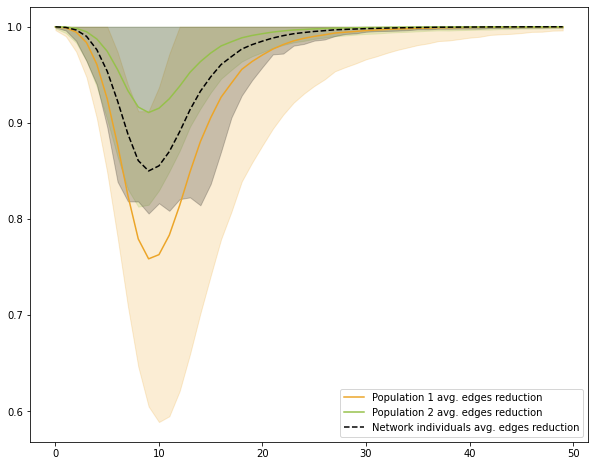

In [100]:
plt.figure(figsize=(10,8))

plt.plot(range(50), df[df['pop']==1]['mean'][0:50],'#ECA528', label="Population 1 avg. edges reduction")
plt.fill_between(range(50),
                df[df['pop']==1]['lower'][0:50],
                df[df['pop']==1]['upper'][0:50],
                color='#ECA528', alpha=0.2)

plt.plot(range(50), df[df['pop']==2]['mean'][0:50],'#96C14B', label="Population 2 avg. edges reduction")
plt.fill_between(range(50),
                df[df['pop']==2]['lower'][0:50],
                df[df['pop']==2]['upper'][0:50],
                color='#96C14B', alpha=0.2)

plt.plot(mean_all[0:50], linestyle='--', color='k', label="Network individuals avg. edges reduction")
plt.fill_between(range(50), upper_all[0:50], lower_all[0:50], color='k', alpha=0.2)

plt.legend(loc="lower right")
plt.show()

### Bifurcation plot examination
Not important ...

In [71]:
# epidist_data = pd.read_csv('./Data/epidist_bifurcation.csv')
# bepidist_data = pd.read_csv('./Data/bepidist_bifurcation.csv')
# epidist_data =  epidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
# epidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
# 'r_mean', 'r_min', 'r_max', 'pi', 'pr']
# epidist_data = epidist_data.apply(pd.to_numeric)
# epidist_data
# bepidist_data = bepidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
# bepidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
#                          'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
# 'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'pi', 'pr']
# bepidist_data = bepidist_data.apply(pd.to_numeric)
# bepidist_data
# dat = pd.DataFrame(epidist_data.groupby(['pi'])['i_mean'].mean()).reset_index()
# plt.scatter(dat['pi'], dat['i_mean'])
# plt.show()
# dat = pd.DataFrame(bepidist_data.groupby(['pi'])['i_mean'].mean()).reset_index()
# plt.scatter(dat['pi'], dat['i_mean'])
# plt.show()
# dat1 = epidist_data[epidist_data['pi']==0.0069]
# dat2 = bepidist_data[bepidist_data['pi']==0.0069]
# print(dat1['i_mean'].max())
# print(dat2['i_mean'].max())
# print(dat1['i_mean'].mean())
# print(dat2['i_mean'].mean())
# plt.plot(range(dat1.shape[0]), dat1['i_mean'], range(dat1.shape[0]), dat2['i_mean'])
# plt.show()
# diffs = []
# mean_diffs = []
# for pi in epidist_data['pi'].unique().tolist():
#     dat1 = epidist_data[epidist_data['pi']==pi]
#     dat2 = bepidist_data[bepidist_data['pi']==pi]
#     diff = dat1['i_mean'].max() - dat2['i_mean'].max()
#     diffs.append(diff)
#     mean_diff = dat1['i_mean'].mean() - dat2['i_mean'].mean()
#     mean_diffs.append(mean_diff)
# plt.plot(epidist_data['pi'].unique().tolist(), mean_diffs)
# plt.show()
# plt.plot(epidist_data['pi'].unique().tolist(), diffs)
# plt.show()

## Sensitivity to network connectivity

Experiment with Erdos-Renyi

In [6]:
bepidist_data_c = pd.read_csv('./Data/bepidist_ntwk_conn_erdos_renyi.csv')
bepidist_data_c = bepidist_data_c.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data_c.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
                         'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'ped']
bepidist_data_c = bepidist_data_c.apply(pd.to_numeric)
conns = bepidist_data_c['ped'].unique().tolist()[5:]
conns = [con for con in conns if con >=0.01]

In [7]:
day_lags = []
for conn in conns:

    bepidist = bepidist_data_c.copy()
    bepidist = bepidist[bepidist['ped'] == conn]

    i_mean = bepidist['i_mean'].astype(float).tolist()
    i_mean = [i/500 for i in i_mean]

    i_min = bepidist['i_min'].astype(float).tolist()
    i_min = [i/500 for i in i_min]

    i_max = bepidist['i_max'].astype(float).tolist()
    i_max = [i/500 for i in i_max]

    mean_all = bepidist['edgecount_mean'].astype(float).tolist()
    lower_all = bepidist['edgecount_min'].astype(float).tolist()
    upper_all = bepidist['edgecount_max'].astype(float).tolist()

    mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
    lower_sus = bepidist['suscedgecount_min'].astype(float).tolist()
    upper_sus = bepidist['suscedgecount_max'].astype(float).tolist()
    
    day_lags.append(np.nanargmin(mean_sus) - np.nanargmin(mean_all))

    # plt.figure()
    # days = 50
    # plt.plot(mean_all[0:days],'-k', label="Network avg. edges reduction")
    # plt.fill_between(list(range(len(mean_all[0:days]))), upper_all[0:days], lower_all[0:days], color="k", alpha=0.2)
    # plt.plot(mean_sus[0:days], linestyle='--', color='b', label="Individuals avg. edges reduction")
    # plt.fill_between(list(range(len(mean_sus[0:days]))), upper_sus[0:days], lower_sus[0:days], color="b", alpha=0.2)
    # plt.plot(i_mean[0:days],'-r', label="Infected Proportion")
    # plt.fill_between(list(range(len(i_mean[0:days]))), i_max[0:days], i_min[0:days], color="r", alpha=0.2)
    # plt.legend(loc="lower right")
    # plt.title(f"Edge reduction (global/local) and infected population. Connectivity={conn}")
    # plt.xlabel("Time")
    # plt.show()

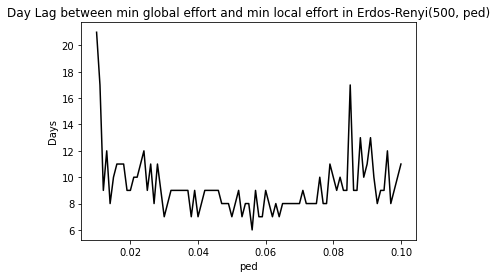

In [8]:
plt.figure()
plt.plot(conns, day_lags,'-k', label="Network avg. edges reduction")
plt.title("Day Lag between min global effort and min local effort in Erdos-Renyi(500, ped)")
plt.xlabel("ped")
plt.ylabel("Days")
plt.show()

### Barabasi Albert Network

In [58]:
bepidist_data_ba = pd.read_csv('./Data/bepidist_ntwk_barabasi_albert.csv')
bepidist_data_ba = bepidist_data_ba.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data_ba.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
                         'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'm']
bepidist_data_ba = bepidist_data_ba.apply(pd.to_numeric)
mms = bepidist_data_ba['m'].unique().tolist()

In [60]:
day_lags = []

for m in mms:
    
    bepidist = bepidist_data_ba.copy()
    bepidist = bepidist[bepidist['m'] == m]

    i_mean = bepidist['i_mean'].astype(float).tolist()
    i_mean = [i/500 for i in i_mean]

    i_min = bepidist['i_min'].astype(float).tolist()
    i_min = [i/500 for i in i_min]

    i_max = bepidist['i_max'].astype(float).tolist()
    i_max = [i/500 for i in i_max]

    mean_all = bepidist['edgecount_mean'].astype(float).tolist()
    lower_all = bepidist['edgecount_min'].astype(float).tolist()
    upper_all = bepidist['edgecount_max'].astype(float).tolist()

    mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
    lower_sus = bepidist['suscedgecount_min'].astype(float).tolist()
    upper_sus = bepidist['suscedgecount_max'].astype(float).tolist()

    day_lags.append(np.nanargmin(mean_sus) - np.nanargmin(mean_all))

    # plt.figure()
    # days = 50
    # plt.plot(mean_all[0:days],'-k', label="Network avg. edges reduction")
    # plt.fill_between(list(range(len(mean_all[0:days]))), upper_all[0:days], lower_all[0:days], color="k", alpha=0.2)
    # plt.plot(mean_sus[0:days], linestyle='--', color='b', label="Individuals avg. edges reduction")
    # plt.fill_between(list(range(len(mean_sus[0:days]))), upper_sus[0:days], lower_sus[0:days], color="b", alpha=0.2)
    # plt.plot(i_mean[0:days],'-r', label="Infected Proportion")
    # plt.fill_between(list(range(len(i_mean[0:days]))), i_max[0:days], i_min[0:days], color="r", alpha=0.2)
    # plt.legend(loc="lower right")
    # plt.title(f"Edge reduction (global/local) and infected population. Barabasi-Alberti(500, {int(m)})")
    # plt.xlabel("Time")
    # plt.show()

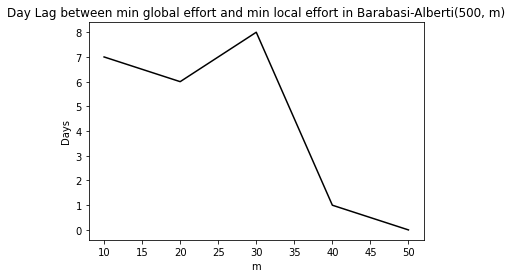

In [61]:
plt.figure()
days = 50
plt.plot(mms, day_lags,'-k', label="Network avg. edges reduction")
plt.title("Day Lag between min global effort and min local effort in Barabasi-Albert(500, m)")
plt.xlabel("m")
plt.ylabel("Days")
plt.show()

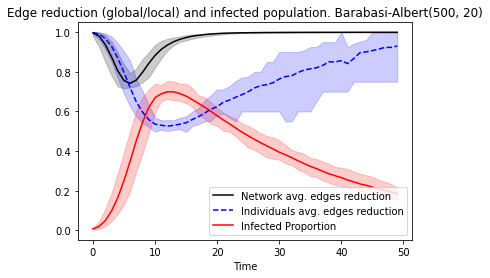

In [74]:
m = 20 
bepidist = bepidist_data_ba.copy()
bepidist = bepidist[bepidist['m'] == m]

i_mean = bepidist['i_mean'].astype(float).tolist()
i_mean = [i/500 for i in i_mean]

i_min = bepidist['i_min'].astype(float).tolist()
i_min = [i/500 for i in i_min]

i_max = bepidist['i_max'].astype(float).tolist()
i_max = [i/500 for i in i_max]

mean_all = bepidist['edgecount_mean'].astype(float).tolist()
lower_all = bepidist['edgecount_min'].astype(float).tolist()
upper_all = bepidist['edgecount_max'].astype(float).tolist()

mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
lower_sus = bepidist['suscedgecount_min'].astype(float).tolist()
upper_sus = bepidist['suscedgecount_max'].astype(float).tolist()

day_lags.append(np.nanargmin(mean_sus) - np.nanargmin(mean_all))

plt.figure()
days = 50
plt.plot(mean_all[0:days],'-k', label="Network avg. edges reduction")
plt.fill_between(list(range(len(mean_all[0:days]))), upper_all[0:days], lower_all[0:days], color="k", alpha=0.2)
plt.plot(mean_sus[0:days], linestyle='--', color='b', label="Individuals avg. edges reduction")
plt.fill_between(list(range(len(mean_sus[0:days]))), upper_sus[0:days], lower_sus[0:days], color="b", alpha=0.2)
plt.plot(i_mean[0:days],'-r', label="Infected Proportion")
plt.fill_between(list(range(len(i_mean[0:days]))), i_max[0:days], i_min[0:days], color="r", alpha=0.2)
plt.legend(loc="lower right")
plt.title(f"Edge reduction (global/local) and infected population. Barabasi-Albert(500, {int(m)})")
plt.xlabel("Time")
plt.show()

### Small world network

- n : int
The number of nodes

- k : int
Each node is connected to k nearest neighbors in ring topology

- p : float
The probability of rewiring each edge

In [25]:
bepidist_data_sw = pd.read_csv('./Data/bepidist_ntwk_small_world.csv')
bepidist_data_sw = bepidist_data_sw.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data_sw.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
                         'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'm', 'ped']
bepidist_data_sw = bepidist_data_sw.apply(pd.to_numeric)

In [45]:
dat_ = pd.DataFrame({})

for m in bepidist_data_sw['m'].unique():
    for ped in bepidist_data_sw['ped'].unique():
        
        bepidist = bepidist_data_sw[(bepidist_data_sw['m']==m) & (bepidist_data_sw['ped']==ped)]
        mean_all = bepidist['edgecount_mean'].astype(float).tolist()
        mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
        day_lag = np.nanargmin(mean_sus) - np.nanargmin(mean_all)
        
        dat_ = pd.concat([dat_, pd.DataFrame({
            'm': [int(m)],
            'ped': [ped],
            'day_lag': [day_lag]
        })], ignore_index=True)

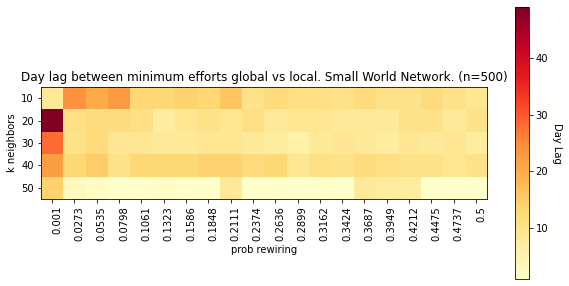

In [48]:
plot1_data = dat_.pivot(index='ped', columns='m', values='day_lag')

# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = "YlOrRd")

ax.figure.set_size_inches(10, 5)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 90,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Day Lag", rotation = -90, va = "bottom")
plt.title(f"Day lag between minimum efforts global vs local. Small World Network. (n=500)")
plt.xlabel("prob rewiring")
plt.ylabel("k neighbors") 
plt.show()
# Add 2D lines several lines.

In [50]:
bepidist_data_sw['ped'].unique()

array([0.001 , 0.0273, 0.0535, 0.0798, 0.1061, 0.1323, 0.1586, 0.1848,
       0.2111, 0.2374, 0.2636, 0.2899, 0.3162, 0.3424, 0.3687, 0.3949,
       0.4212, 0.4475, 0.4737, 0.5   ])

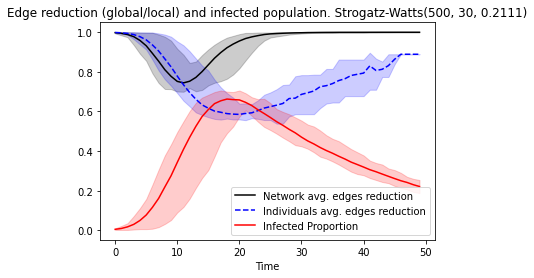

In [52]:
m = 30
ped = 0.2111

bepidist = bepidist_data_sw[(bepidist_data_sw['m']==m) & (bepidist_data_sw['ped']==ped)]

i_mean = bepidist['i_mean'].astype(float).tolist()
i_mean = [i/500 for i in i_mean]

i_min = bepidist['i_min'].astype(float).tolist()
i_min = [i/500 for i in i_min]

i_max = bepidist['i_max'].astype(float).tolist()
i_max = [i/500 for i in i_max]

mean_all = bepidist['edgecount_mean'].astype(float).tolist()
lower_all = bepidist['edgecount_min'].astype(float).tolist()
upper_all = bepidist['edgecount_max'].astype(float).tolist()

mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
lower_sus = bepidist['suscedgecount_min'].astype(float).tolist()
upper_sus = bepidist['suscedgecount_max'].astype(float).tolist()

day_lags.append(np.nanargmin(mean_sus) - np.nanargmin(mean_all))

plt.figure()
days = 50
plt.plot(mean_all[0:days],'-k', label="Network avg. edges reduction")
plt.fill_between(list(range(len(mean_all[0:days]))), upper_all[0:days], lower_all[0:days], color="k", alpha=0.2)
plt.plot(mean_sus[0:days], linestyle='--', color='b', label="Individuals avg. edges reduction")
plt.fill_between(list(range(len(mean_sus[0:days]))), upper_sus[0:days], lower_sus[0:days], color="b", alpha=0.2)
plt.plot(i_mean[0:days],'-r', label="Infected Proportion")
plt.fill_between(list(range(len(i_mean[0:days]))), i_max[0:days], i_min[0:days], color="r", alpha=0.2)
plt.legend(loc="lower right")
plt.title(f"Edge reduction (global/local) and infected population. Watts-Strogatz(500, {int(m)}, {ped})")
plt.xlabel("Time")
plt.show()

## Articles of interest:
- https://www.pnas.org/doi/10.1073/pnas.2123355119
- https://journals.aps.org/pre/pdf/10.1103/PhysRevE.88.042802
- https://journals.aps.org/pre/pdf/10.1103/PhysRevE.77.066101
- https://journals.aps.org/prl/pdf/10.1103/PhysRevLett.96.208701
- https://www.sciencedirect.com/science/article/pii/S0022039618304182
- https://ieeexplore.ieee.org/abstract/document/8502826